=== AuraBio.AI Feature Matrix Verification ===
Ingested Tissue Block Format : torch.Size([1, 3, 224, 224])
Transformer Sequence Output  : torch.Size([1, 196, 768])



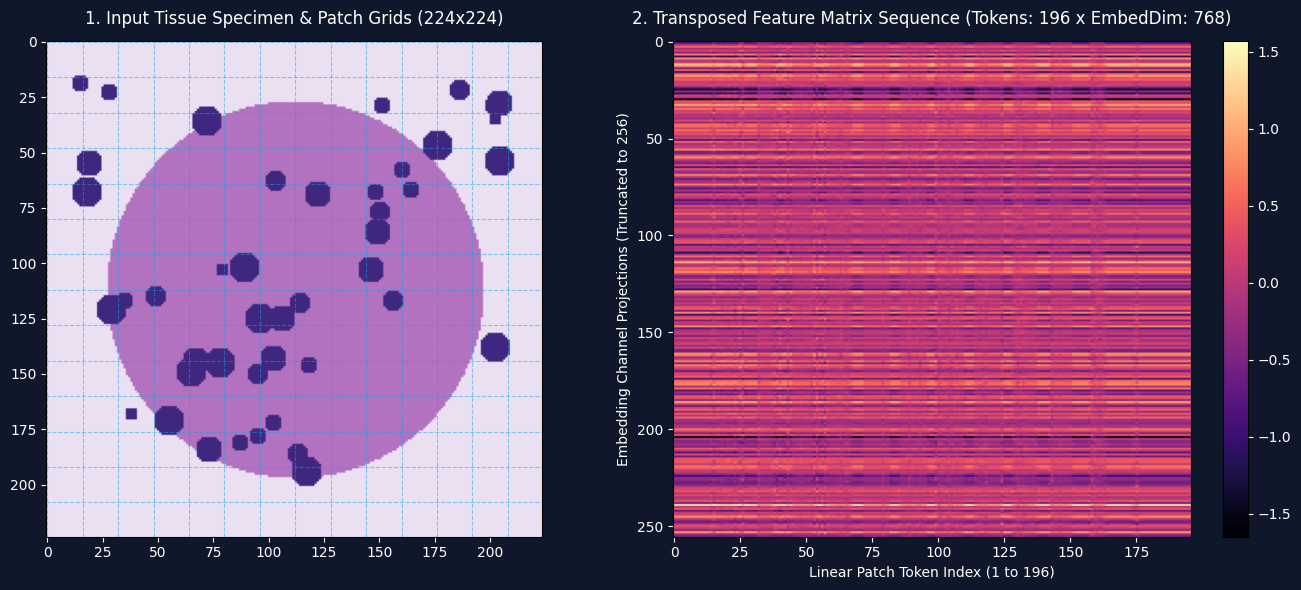

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

class ViTPatchEmbedding(nn.Module):
    """
    Extracts multi-channel morphological feature maps from raw tissue blocks.

    Input Shape:
        (Batch, Channels, Height, Width) -> (B, 3, 224, 224)
    Output Shape:
        (Batch, SequenceLen, FeatureDim) -> (B, 196, 768)
    """
    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        in_chans: int = 3,
        embed_dim: int = 768
    ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        # FIXED: Corrected syntax error, renamed arg to kernel_size,
        # and matched stride to patch_size for non-overlapping windows.
        self.proj = nn.Conv2d(
            in_channels=in_chans,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Expected input shape: (B, 3, 224, 224)
        x = self.proj(x)        # Resulting shape: (B, 768, 14, 14)
        x = x.flatten(2)        # Resulting shape: (B, 768, 196)
        x = x.transpose(1, 2)   # Resulting shape: (B, 196, 768)
        return x

# =========================================================================
# SYSTEM EXECUTION & VISUALIZATION PIPELINE
# =========================================================================

def run_pipeline_demo():
    # 1. Initialize configuration parameters
    patch_size = 16
    embed_dim = 768
    embedder = ViTPatchEmbedding(img_size=224, patch_size=patch_size, embed_dim=embed_dim)

    # 2. Generate a synthetic digital pathology slide (H&E color profile simulation)
    mock_tissue = np.zeros((224, 224, 3), dtype=np.float32)
    y, x = np.ogrid[:224, :224]

    # Structural Tumor Nest (simulated pinkish-purple cell mass)
    tumor_mask = ((x - 112)**2 + (y - 112)**2 < 85**2)
    mock_tissue[tumor_mask] = [0.70, 0.45, 0.75]  # Eosin/Hematoxylin mix
    mock_tissue[~tumor_mask] = [0.92, 0.88, 0.95] # Stromal/background architecture

    # Inject scattered dense cellular nuclei (dark purple/blue points)
    np.random.seed(42)
    for _ in range(45):
        nx, ny = np.random.randint(15, 205, size=2)
        nuclei_mask = ((x - nx)**2 + (y - ny)**2 < np.random.randint(3, 8)**2)
        mock_tissue[nuclei_mask] = [0.25, 0.15, 0.50]

    # Reorder dimensions for PyTorch format: (H, W, C) -> (Batch=1, C, H, W)
    input_tensor = torch.from_numpy(mock_tissue).permute(2, 0, 1).unsqueeze(0)

    # 3. Process image tensor through patch embedding framework
    embedder.eval()
    with torch.no_grad():
        output_embeddings = embedder(input_tensor)

    # Console diagnostics printout
    print("=== AuraBio.AI Feature Matrix Verification ===")
    print(f"Ingested Tissue Block Format : {input_tensor.shape}")
    print(f"Transformer Sequence Output  : {output_embeddings.shape}\n")

    # 4. Generate Interactive Plots using UI theme accents
    fig = plt.figure(figsize=(14, 6))
    fig.patch.set_facecolor('#0F172A')  # Theme matching Core Application dashboard

    # Plot 1: Source Tissue with sliding 2D patch grids
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(mock_tissue)
    ax1.set_title("1. Input Tissue Specimen & Patch Grids (224x224)", color='white', fontsize=12, pad=12)

    # Grid lines to visually illustrate patch quantization boundaries
    for step in range(0, 224, patch_size):
        ax1.axhline(step, color='#0EA5E9', linestyle='--', alpha=0.5, linewidth=0.8)
        ax1.axvline(step, color='#0EA5E9', linestyle='--', alpha=0.5, linewidth=0.8)
    ax1.tick_params(colors='white')

    # Plot 2: Transposed feature space matrix map
    ax2 = plt.subplot(1, 2, 2)
    # Project a slice of the 768-dimensional space onto the canvas for clean rendering
    matrix_slice = output_embeddings.squeeze(0).numpy()[:, :256]
    img_plot = ax2.imshow(matrix_slice.T, cmap='magma', aspect='auto')

    ax2.set_title(f"2. Transposed Feature Matrix Sequence (Tokens: {output_embeddings.shape[1]} x EmbedDim: {embed_dim})",
                  color='white', fontsize=12, pad=12)
    ax2.set_xlabel("Linear Patch Token Index (1 to 196)", color='white', fontsize=10)
    ax2.set_ylabel("Embedding Channel Projections (Truncated to 256)", color='white', fontsize=10)
    ax2.tick_params(colors='white')

    colorbar = fig.colorbar(img_plot, ax=ax2)
    colorbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_pipeline_demo()